In [1]:
import chainlit as cl 
from typing import TypedDict, List
from langgraph.graph import StateGraph
from langchain_ollama import ChatOllama
import os
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage

#Initialize LLM
llm = ChatOllama(model="qwen3:4b", streaming=True)

#Define agent state
class AgentState(TypedDict):
    messages : List[BaseMessage]

#LangGraph node
def llm_node(state : AgentState) -> AgentState:
    response = llm.invoke(state["messages"])

    state["messages"] = state["messages"] + [AIMessage(content=response.content)]

    print("\nState after LLM", state)
    return state


#Build LangGraph
graph = StateGraph(AgentState)
graph.add_node("llm", llm_node)
graph.set_entry_point("llm")
graph.set_finish_point("llm")
agent = graph.compile()


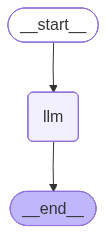

In [2]:
from IPython.display import display, Image
display(Image(agent.get_graph().draw_mermaid_png()))